In [71]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [72]:
df1 = pd.read_csv("Delhi_v2.csv")
df1.head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,Status,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft
0,0,5600000.0,"Noida Extension, Noida, Delhi NCR",1350,28.608850,77.460560,3,3,NaN,Under Construction,New Property,NaN,NaN,2.0,NaN,Flat,\n\n\n Welcome ...,4148.148148
1,1,8800000.0,"Sector 79, Gurgaon, Delhi NCR",1490,28.374236,76.952416,3,3,NaN,Ready to Move,New Property,NaN,Semi-Furnished,2.0,NaN,Flat,\n\n\n Mapsko M...,5906.040268
2,2,16500000.0,"Vaishali, Ghaziabad, Delhi NCR",2385,28.645769,77.385110,4,5,NaN,Ready to Move,New Property,1.0,Unfurnished,NaN,NaN,Flat,\n\n\n This pro...,6918.238994
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,3.0,NaN,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429
4,4,6200000.0,"Jaypee Pavilion Court Sector 128, Noida, Secto...",1350,28.520732,77.356491,2,2,3.0,Ready to Move,Resale,1.0,NaN,3.0,NaN,Flat,\n\n\n The prop...,4592.592593


In [73]:
df1.shape

(7738, 18)

In [74]:
# First recreate the area_type column
df1['area_type'] = pd.cut(df1['area'], bins=[0, 1000, 3000, df1['area'].max()], labels=['Small', 'Medium', 'Large'])

# Now group by area_type
df1.groupby('area_type')['area_type'].agg('count')

/tmp/ipykernel_618/1132464368.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('area_type')['area_type'].agg('count')


,area_type
area_type,
Small,2261
Medium,5240
Large,237


In [75]:
print("df1 columns:")
print(df1.columns.tolist())

df1 columns:
['Serial No.', 'price', 'Address', 'area', 'latitude', 'longitude', 'Bedrooms', 'Bathrooms', 'Balcony', 'Status', 'neworold', 'parking', 'Furnished_status', 'Lift', 'Landmarks', 'type_of_building', 'desc', 'Price_sqft', 'area_type']


In [76]:
print("df2 columns:")
print(df1.columns.tolist())

df2 columns:
['Serial No.', 'price', 'Address', 'area', 'latitude', 'longitude', 'Bedrooms', 'Bathrooms', 'Balcony', 'Status', 'neworold', 'parking', 'Furnished_status', 'Lift', 'Landmarks', 'type_of_building', 'desc', 'Price_sqft', 'area_type']


In [77]:
df1.describe()

,Serial No.,price,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,parking,Lift,Price_sqft
count,7738.000000,7.738000e+03,7738.000000,7738.000000,7738.000000,7738.000000,7738.000000,5166.000000,2612.000000,1733.000000,7738.000000
mean,3868.500000,8.320635e+06,1409.506591,28.552092,77.273476,2.708193,2.501163,2.426442,7.673047,1.829198,5543.660241
std,2233.912524,7.223197e+06,718.929581,0.107420,0.180606,0.877026,0.867050,1.083677,60.417508,1.192607,2408.659307
min,0.000000,1.700000e+06,501.000000,28.240023,76.884101,2.000000,2.000000,1.000000,1.000000,0.000000,2100.000000
25%,1934.250000,4.200000e+06,990.000000,28.455539,77.078590,2.000000,2.000000,2.000000,1.000000,1.000000,3950.986915
50%,3868.500000,6.000000e+06,1250.000000,28.574637,77.345320,3.000000,2.000000,2.000000,1.000000,2.000000,4972.674332
75%,5802.750000,9.500000e+06,1650.000000,28.642520,77.421054,3.000000,3.000000,3.000000,2.000000,2.000000,6350.638693
max,7737.000000,8.500000e+07,9500.000000,28.799748,77.688028,10.000000,10.000000,10.000000,1406.000000,10.000000,44378.698225


In [78]:
df1.head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,Status,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type
0,0,5600000.0,"Noida Extension, Noida, Delhi NCR",1350,28.608850,77.460560,3,3,NaN,Under Construction,New Property,NaN,NaN,2.0,NaN,Flat,\n\n\n Welcome ...,4148.148148,Medium
1,1,8800000.0,"Sector 79, Gurgaon, Delhi NCR",1490,28.374236,76.952416,3,3,NaN,Ready to Move,New Property,NaN,Semi-Furnished,2.0,NaN,Flat,\n\n\n Mapsko M...,5906.040268,Medium
2,2,16500000.0,"Vaishali, Ghaziabad, Delhi NCR",2385,28.645769,77.385110,4,5,NaN,Ready to Move,New Property,1.0,Unfurnished,NaN,NaN,Flat,\n\n\n This pro...,6918.238994,Medium
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,3.0,NaN,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium
4,4,6200000.0,"Jaypee Pavilion Court Sector 128, Noida, Secto...",1350,28.520732,77.356491,2,2,3.0,Ready to Move,Resale,1.0,NaN,3.0,NaN,Flat,\n\n\n The prop...,4592.592593,Medium


In [79]:
# safe drop with existing column names
cols_to_drop = ['Balcony', 'Status']
df2 = df1.drop(cols_to_drop, axis='columns', errors='ignore')
df2.head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type
0,0,5600000.0,"Noida Extension, Noida, Delhi NCR",1350,28.608850,77.460560,3,3,New Property,NaN,NaN,2.0,NaN,Flat,\n\n\n Welcome ...,4148.148148,Medium
1,1,8800000.0,"Sector 79, Gurgaon, Delhi NCR",1490,28.374236,76.952416,3,3,New Property,NaN,Semi-Furnished,2.0,NaN,Flat,\n\n\n Mapsko M...,5906.040268,Medium
2,2,16500000.0,"Vaishali, Ghaziabad, Delhi NCR",2385,28.645769,77.385110,4,5,New Property,1.0,Unfurnished,NaN,NaN,Flat,\n\n\n This pro...,6918.238994,Medium
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium
4,4,6200000.0,"Jaypee Pavilion Court Sector 128, Noida, Secto...",1350,28.520732,77.356491,2,2,Resale,1.0,NaN,3.0,NaN,Flat,\n\n\n The prop...,4592.592593,Medium


In [80]:
df2.isnull().sum()

,0
Serial No.,0
price,0
Address,0
area,0
latitude,0
longitude,0
Bedrooms,0
Bathrooms,0
neworold,0
parking,5126


In [81]:
df3 = df2.dropna()
df3.isnull().sum()

,0
Serial No.,0
price,0
Address,0
area,0
latitude,0
longitude,0
Bedrooms,0
Bathrooms,0
neworold,0
parking,0


In [82]:
df3.shape

(413, 17)

In [83]:
print(df3.columns.tolist())

['Serial No.', 'price', 'Address', 'area', 'latitude', 'longitude', 'Bedrooms', 'Bathrooms', 'neworold', 'parking', 'Furnished_status', 'Lift', 'Landmarks', 'type_of_building', 'desc', 'Price_sqft', 'area_type']


In [84]:
# ensure 'size' column exists before accessing
define_size = False
if 'size' not in df3.columns:
    # create a size column from area if appropriate
    print("'size' column missing; creating from 'area'")
    df3['size'] = df3['area']
    define_size = True
else:
    print("'size' column already present")

# now safely inspect unique values
print(df3['size'].unique())

'size' column missing; creating from 'area'
[1050  850 1000 1450 1087 1845 1481  950 1689 1685 1170 1275  800 1365
 1260 1600 1150 1935  770 1065 3500  750 1460  540 1250 1008 2800 1100
 1658 2700 1500 1475 2400 2430 1800 2300 1362 1775 1695 1675 3050 1180
  700  600 2000 1330 1900  900 1110 1277 1954 1355 2050 2860 1300 1725
 3600 4300  990 1700 1850 3700 1265 1930 2150 1120  760 1114  720 1528
  645  935 1895 1190 2387 1630  966  650 1660 4000 1852 1400 1185 1728
 1350 1551 1750 2225  801  962 1106 2250 1020 2336 1574 1839 1255 1530
  945 2445 2175 2259 1890 1980 4200 2100 1585  642  761 4545  972 3000
  550 2549  930 1200 1625 2850  965 1230 1495 1380 1179  860 1286  910
 2052 1435  890 1144  845  780 1075  675  805 1440 3300 1175 1058 1540
  648 1570 2240  969 1105  891 1280  560  825 2200  865 1345 1290  880
  925 2600 1414  915  810 1945 1836  680 1955 2160 1478 1030 4500 2124
 2500  630 1950 1505 1480 1152 2367  848 1262 1368 1040 1425 3284 1704
  984 3150 1720 1406 1070 1550 10

/tmp/ipykernel_618/709692887.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['size'] = df3['area']


In [85]:
# derive bhk; size may be numeric so fall back to Bedrooms
if 'Bedrooms' in df3.columns:
    df3['bhk'] = df3['Bedrooms']
else:
    df3['bhk'] = df3['size'].astype(str).str.split().str[0]

# display unique bhk counts
print(df3['bhk'].unique())

[2 3 4 5]


/tmp/ipykernel_618/3407153386.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['Bedrooms']


In [86]:
df3.head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium,1050,2
10,10,7300000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",850,28.724075,77.095581,3,2,New Property,2.0,Semi-Furnished,1.0,Near by shri jagannath mandir,Flat,\n\n\n 3 BHK se...,8588.235294,Small,850,3
15,15,9500000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1000,28.721436,77.107018,3,2,New Property,2.0,Semi-Furnished,1.0,Near by the sovereign school,Individual House,\n \n \n...,9500.000000,Small,1000,3
16,16,15000000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1450,28.727213,77.096062,4,3,New Property,2.0,Semi-Furnished,1.0,Near by shri jagannath mandir,Individual House,\n\n\n 4 BHK th...,10344.827586,Medium,1450,4
18,18,5100000.0,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.644310,77.331787,2,2,Resale,1.0,Semi-Furnished,2.0,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,Medium,1087,2


In [87]:
df3['bhk'].unique()

array([2, 3, 4, 5])

In [88]:
df3[df3.bhk>10]

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk


In [89]:
# check available columns for sqft-related data
sqft_cols = [col for col in df3.columns if 'sqft' in col.lower() or 'area' in col.lower()]
print("Available area/sqft columns:", sqft_cols)

# use area or Price_sqft if available
if 'area' in df3.columns:
    print(df3['area'].unique())
elif 'Price_sqft' in df3.columns:
    print(df3['Price_sqft'].unique())
else:
    print("No sqft or area column found")

Available area/sqft columns: ['area', 'Price_sqft', 'area_type']
[1050  850 1000 1450 1087 1845 1481  950 1689 1685 1170 1275  800 1365
 1260 1600 1150 1935  770 1065 3500  750 1460  540 1250 1008 2800 1100
 1658 2700 1500 1475 2400 2430 1800 2300 1362 1775 1695 1675 3050 1180
  700  600 2000 1330 1900  900 1110 1277 1954 1355 2050 2860 1300 1725
 3600 4300  990 1700 1850 3700 1265 1930 2150 1120  760 1114  720 1528
  645  935 1895 1190 2387 1630  966  650 1660 4000 1852 1400 1185 1728
 1350 1551 1750 2225  801  962 1106 2250 1020 2336 1574 1839 1255 1530
  945 2445 2175 2259 1890 1980 4200 2100 1585  642  761 4545  972 3000
  550 2549  930 1200 1625 2850  965 1230 1495 1380 1179  860 1286  910
 2052 1435  890 1144  845  780 1075  675  805 1440 3300 1175 1058 1540
  648 1570 2240  969 1105  891 1280  560  825 2200  865 1345 1290  880
  925 2600 1414  915  810 1945 1836  680 1955 2160 1478 1030 4500 2124
 2500  630 1950 1505 1480 1152 2367  848 1262 1368 1040 1425 3284 1704
  984 3150 1

In [90]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

In [91]:
# use 'area' column instead of non-existent 'total_sqft'
df3[~df3['area'].apply(is_float)].head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk


In [92]:
def convert_sqft_to_num(x):
    try:
        return float(x)
    except:
        if isinstance(x, str):
            if '-' in x:
                tokens = x.split('-')
                if len(tokens) == 2:
                    try:
                        return (float(tokens[0].strip()) + float(tokens[1].strip())) / 2
                    except:
                        return None
            elif 'sqft' in x.lower():
                try:
                    return float(x.lower().replace('sqft', '').strip())
                except:
                    return None
        return None

In [93]:
convert_sqft_to_num('2100-2850')

2475.0

In [94]:
convert_sqft_to_num('2100-2850')

2475.0

In [95]:
convert_sqft_to_num('34.465q. Meter')

In [96]:
df4 = df3.copy()
df4 ['total_sqft'] = df4['area'].apply(convert_sqft_to_num)
df4.head(3)

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium,1050,2,1050.0
10,10,7300000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",850,28.724075,77.095581,3,2,New Property,2.0,Semi-Furnished,1.0,Near by shri jagannath mandir,Flat,\n\n\n 3 BHK se...,8588.235294,Small,850,3,850.0
15,15,9500000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1000,28.721436,77.107018,3,2,New Property,2.0,Semi-Furnished,1.0,Near by the sovereign school,Individual House,\n \n \n...,9500.000000,Small,1000,3,1000.0


In [97]:
df4.loc[30]

,30
Serial No.,30
price,9000000.0
Address,"sector 103 gurgaon, Dwarka Expressway, Gurgaon..."
area,1481
latitude,28.49745
longitude,77.027092
Bedrooms,2
Bathrooms,2
neworold,Resale
parking,2.0


In [98]:
2100+2850/2

3525.0

In [99]:
df4.head(3)

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,New Property,1.0,Unfurnished,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium,1050,2,1050.0
10,10,7300000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",850,28.724075,77.095581,3,2,New Property,2.0,Semi-Furnished,1.0,Near by shri jagannath mandir,Flat,\n\n\n 3 BHK se...,8588.235294,Small,850,3,850.0
15,15,9500000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1000,28.721436,77.107018,3,2,New Property,2.0,Semi-Furnished,1.0,Near by the sovereign school,Individual House,\n \n \n...,9500.000000,Small,1000,3,1000.0


In [100]:
print("df4 columns:")
print(df4.columns.tolist())

df4 columns:
['Serial No.', 'price', 'Address', 'area', 'latitude', 'longitude', 'Bedrooms', 'Bathrooms', 'neworold', 'parking', 'Furnished_status', 'Lift', 'Landmarks', 'type_of_building', 'desc', 'Price_sqft', 'area_type', 'size', 'bhk', 'total_sqft']


In [101]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price'] / df5['total_sqft']
df5.head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,...,Lift,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft,price_per_sqft
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,New Property,1.0,...,2.0,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium,1050,2,1050.0,3628.571429
10,10,7300000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",850,28.724075,77.095581,3,2,New Property,2.0,...,1.0,Near by shri jagannath mandir,Flat,\n\n\n 3 BHK se...,8588.235294,Small,850,3,850.0,8588.235294
15,15,9500000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1000,28.721436,77.107018,3,2,New Property,2.0,...,1.0,Near by the sovereign school,Individual House,\n \n \n...,9500.000000,Small,1000,3,1000.0,9500.000000
16,16,15000000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1450,28.727213,77.096062,4,3,New Property,2.0,...,1.0,Near by shri jagannath mandir,Individual House,\n\n\n 4 BHK th...,10344.827586,Medium,1450,4,1450.0,10344.827586
18,18,5100000.0,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.644310,77.331787,2,2,Resale,1.0,...,2.0,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,Medium,1087,2,1087.0,4691.812328


In [102]:
len(df5['Address'].unique())

399

In [103]:
df5['address'] = df5['Address'].apply(lambda x: x.split(',')[0].strip())
address_stats = df5.groupby('address')['price_per_sqft'].agg(['mean', 'count']).reset_index()
address_stats

,address,mean,count
0,"""A"" Block DLF Dilshad Extn",3552.631579,1
1,002,6000.000000,1
2,01.,7133.757962,1
3,1.,7777.777778,1
4,1/5141,6448.412698,1
...,...,...,...
371,vaishali,4400.000000,1
372,vaishali Ghaziabad,5373.134328,1
373,vasundhara,3916.666667,1
374,vikas vihar New Delhi,5000.000000,1


In [104]:
len(df5['Address'].unique())

399

In [105]:
len(address_stats[address_stats['count']<=10])

376

In [106]:
address_stats_less_than_10 = address_stats[address_stats['count']<=10]
address_stats_less_than_10

,address,mean,count
0,"""A"" Block DLF Dilshad Extn",3552.631579,1
1,002,6000.000000,1
2,01.,7133.757962,1
3,1.,7777.777778,1
4,1/5141,6448.412698,1
...,...,...,...
371,vaishali,4400.000000,1
372,vaishali Ghaziabad,5373.134328,1
373,vasundhara,3916.666667,1
374,vikas vihar New Delhi,5000.000000,1


In [107]:
len(df5['address'].unique())

376

In [108]:
df5['address'] = df5['address'].apply(lambda x: 'other' if x in address_stats_less_than_10['address'].values else x)
len(df5['address'].unique())

1

In [109]:
print("df5 columns:", df5.columns.tolist())
print("address_stats_less_than_10 columns:", address_stats_less_than_10.columns.tolist())

df5 columns: ['Serial No.', 'price', 'Address', 'area', 'latitude', 'longitude', 'Bedrooms', 'Bathrooms', 'neworold', 'parking', 'Furnished_status', 'Lift', 'Landmarks', 'type_of_building', 'desc', 'Price_sqft', 'area_type', 'size', 'bhk', 'total_sqft', 'price_per_sqft', 'address']
address_stats_less_than_10 columns: ['address', 'mean', 'count']


In [110]:
df5.head(10)

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,...,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft,price_per_sqft,address
3,3,3810000.0,"Link Road, F Block, Sector 50, Noida, Uttar Pr...",1050,28.566914,77.436434,2,2,New Property,1.0,...,near Gaur Mulberry Mansion,Flat,\n\n\n AIG Roya...,3628.571429,Medium,1050,2,1050.0,3628.571429,other
10,10,7300000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",850,28.724075,77.095581,3,2,New Property,2.0,...,Near by shri jagannath mandir,Flat,\n\n\n 3 BHK se...,8588.235294,Small,850,3,850.0,8588.235294,other
15,15,9500000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1000,28.721436,77.107018,3,2,New Property,2.0,...,Near by the sovereign school,Individual House,\n \n \n...,9500.000000,Small,1000,3,1000.0,9500.000000,other
16,16,15000000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",1450,28.727213,77.096062,4,3,New Property,2.0,...,Near by shri jagannath mandir,Individual House,\n\n\n 4 BHK th...,10344.827586,Medium,1450,4,1450.0,10344.827586,other
18,18,5100000.0,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.644310,77.331787,2,2,Resale,1.0,...,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,Medium,1087,2,1087.0,4691.812328,other
19,19,14000000.0,"Sector 45, Noida, Sector 45, Noida, Delhi NCR",1845,28.546930,77.354387,3,3,Resale,2.0,...,noida expressway,Flat,\n \n \n...,7588.075881,Medium,1845,3,1845.0,7588.075881,other
30,30,9000000.0,"sector 103 gurgaon, Dwarka Expressway, Gurgaon...",1481,28.497450,77.027092,2,2,Resale,2.0,...,near gurgaon railway station,Flat,\n \n \n...,6076.975017,Medium,1481,2,1481.0,6076.975017,other
38,38,4550000.0,"Krishna Park Colony, New Delhi - South, Delhi NCR",950,28.508090,77.231467,3,2,New Property,1.0,...,The proprty is located nearby vishal mega mart,Flat,\n\n\n Devli Kh...,4789.473684,Small,950,3,950.0,4789.473684,other
52,52,10000000.0,"Sector 104, Gurgaon, Sector 104, Gurgaon, Delh...",1689,28.487018,76.998009,3,3,New Property,1.0,...,Bang on 150 mtr wide Dwarka Expressway . close...,Flat,\n\n\n A home w...,5920.663114,Medium,1689,3,1689.0,5920.663114,other
55,55,7700000.0,"Sector 137, Noida, Sector 137, Noida, Delhi NCR",1685,28.509208,77.406626,3,4,Resale,1.0,...,Sector 137 Metro Station,Flat,\n \n \n...,4569.732938,Medium,1685,3,1685.0,4569.732938,other


In [111]:
df5[df5.total_sqft/df5.bhk<300].head()

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,...,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft,price_per_sqft,address
10,10,7300000.0,"Sector 24 Rohini, New Delhi - Rohini, Delhi NCR",850,28.724075,77.095581,3,2,New Property,2.0,...,Near by shri jagannath mandir,Flat,\n\n\n 3 BHK se...,8588.235294,Small,850,3,850.0,8588.235294,other
178,178,2550000.0,"Swaroop garden gurgaon, Rajendra Park, Gurgaon...",540,28.497486,77.027130,2,2,Resale,1.0,...,near Rajendra park police station,Flat,\n,4722.222222,Small,540,2,540.0,4722.222222,other
377,377,3500000.0,"vikas vihar New Delhi, Uttam Nagar East, New D...",700,28.634769,77.049026,3,2,New Property,1.0,...,Near Arya samaj Market Road,Individual House,"\n\n\n Hey, hur...",5000.000000,Small,700,3,700.0,5000.000000,other
690,690,4500000.0,"Dwarka Mor, New Delhi - West, Delhi NCR",800,28.619316,77.033264,3,2,New Property,2.0,...,Dwarka mor metro statoin.,Flat,\n\n\n New Proj...,5625.000000,Small,800,3,800.0,5625.000000,other
1127,1127,2630000.0,"Sector 95, Gurgaon, Sector 95, Gurgaon, Delhi NCR",645,28.415022,76.910391,3,2,Resale,6.0,...,Direct connectivity to 150 mtrs Pataudi Road.....,Flat,\n \n \n...,4077.519380,Small,645,3,645.0,4077.519380,other


In [112]:
df5.shape

(413, 22)

In [113]:
# Ensure bhk and address are properly typed and filter out rows where sqft per bedroom is less than 300
df5['bhk'] = pd.to_numeric(df5['bhk'], errors='coerce')
df5['address'] = df5['address'].astype(str)
df6 = df5[~((df5.total_sqft / df5.bhk) < 300)].dropna(subset=['bhk'])
df6.shape

(397, 22)

In [114]:
df6.price_per_sqft.describe()

,price_per_sqft
count,397.000000
mean,6615.755550
std,3109.062023
min,2599.243856
25%,4473.684211
50%,5703.703704
75%,7936.507937
max,24074.074074


In [115]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('address'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df7 = remove_pps_outliers(df6)
df7.shape

(317, 22)

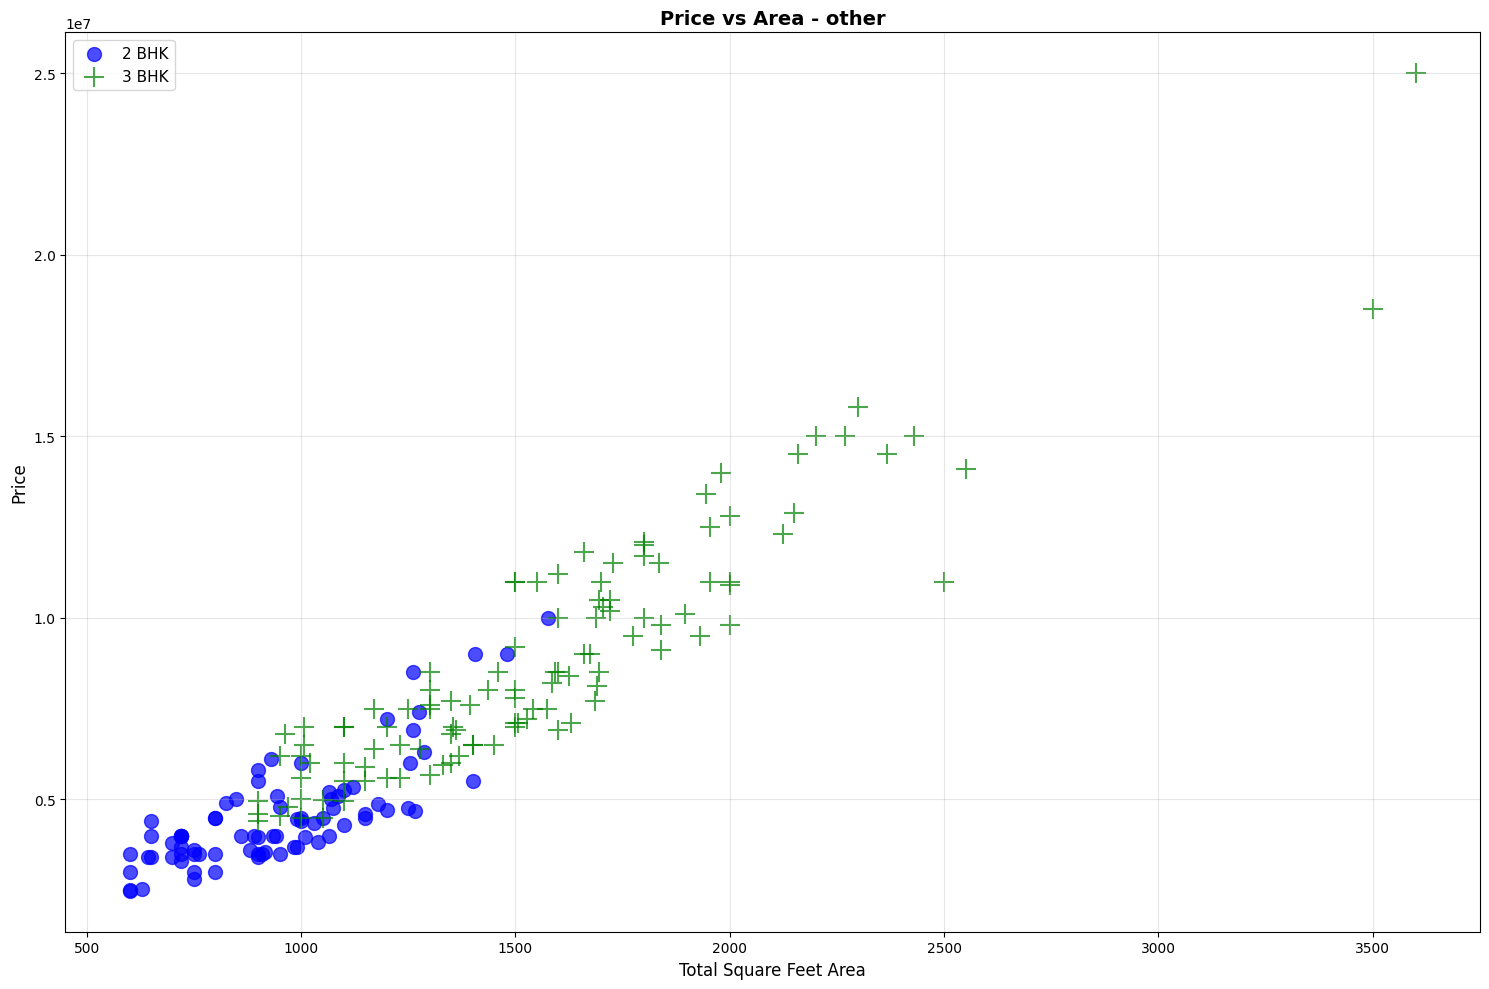


2 BHK count: 80, 3 BHK count: 112


In [116]:
def plot_scatter_chart(df, address=None):
    # If no address specified, find the address with most 2 and 3 BHK properties
    if address is None:
        bhk_data = df[(df.bhk==2) | (df.bhk==3)]
        address = bhk_data['address'].value_counts().index[0]

    bhk2 = df[(df.address==address) & (df.bhk==2)]
    bhk3 = df[(df.address==address) & (df.bhk==3)]

    # Check if we have data for the specified address
    if len(bhk2) == 0 and len(bhk3) == 0:
        print(f"No 2/3 BHK data for '{address}'. Finding address with data...")
        bhk_data = df[(df.bhk==2) | (df.bhk==3)]
        address = bhk_data['address'].value_counts().index[0]
        bhk2 = df[(df.address==address) & (df.bhk==2)]
        bhk3 = df[(df.address==address) & (df.bhk==3)]

    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.figure()
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=100, alpha=0.7)
    plt.scatter(bhk3.total_sqft, bhk3.price, marker='+', color='green', label='3 BHK', s=200, alpha=0.7)
    plt.xlabel("Total Square Feet Area", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.title(f"Price vs Area - {address}", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n2 BHK count: {len(bhk2)}, 3 BHK count: {len(bhk3)}")

plot_scatter_chart(df8)

The `remove_bhk_outliers` function performs the following steps to clean the data:

1.  **Copies DataFrame**: It starts by creating a copy of the input DataFrame (`df`) to ensure that the original data remains unchanged.
2.  **Groups by Address**: It iterates through each unique `address` in the DataFrame.
3.  **Groups by BHK**: Within each `address` group, it further groups the properties by the number of bedrooms (`bhk`).
4.  **Filters by Data Volume**: To ensure statistical relevance, it only considers `bhk` groups that have more than 5 properties.
5.  **Calculates Statistics**: For these qualifying groups, it calculates the mean and standard deviation of the `price_per_sqft`.
6.  **Identifies Outliers**: It then identifies properties where the `price_per_sqft` falls outside the range of (mean - standard deviation) and (mean + standard deviation). These are considered outliers.
7.  **Collects Outlier Indices**: The indices of these identified outliers are collected.
8.  **Removes Outliers**: Finally, all properties corresponding to the collected outlier indices are dropped from the DataFrame.
9.  **Reports Changes**: It prints the number of records before and after outlier removal, along with the total number of outliers removed.

In [117]:
def remove_bhk_outliers(df):
    """
    Remove price per sqft outliers for each BHK type within each address.
    Uses mean ± std approach for outlier detection.
    Only applies to BHK types with more than 5 properties.
    """
    df_out = df.copy()
    indices_to_drop = []

    for address, address_df in df_out.groupby('address'):
        for bhk, bhk_df in address_df.groupby('bhk'):
            if len(bhk_df) > 5:  # Only process if more than 5 properties
                mean_price = bhk_df['price_per_sqft'].mean()
                std_price = bhk_df['price_per_sqft'].std()

                upper_limit = mean_price + std_price
                lower_limit = mean_price - std_price

                # Find outlier indices
                outliers = bhk_df[(bhk_df['price_per_sqft'] > upper_limit) |
                                  (bhk_df['price_per_sqft'] < lower_limit)].index
                indices_to_drop.extend(outliers)

    # Remove outliers
    df_out = df_out.drop(indices_to_drop, errors='ignore')

    print(f"Original records: {len(df)}")
    print(f"Records after removing outliers: {len(df_out)}")
    print(f"Outliers removed: {len(df) - len(df_out)}")

    return df_out

# Create df8 with cleaned data
df8 = remove_bhk_outliers(df7)
print(f"df8 shape: {df8.shape}")

Original records: 317
Records after removing outliers: 218
Outliers removed: 99
df8 shape: (218, 22)


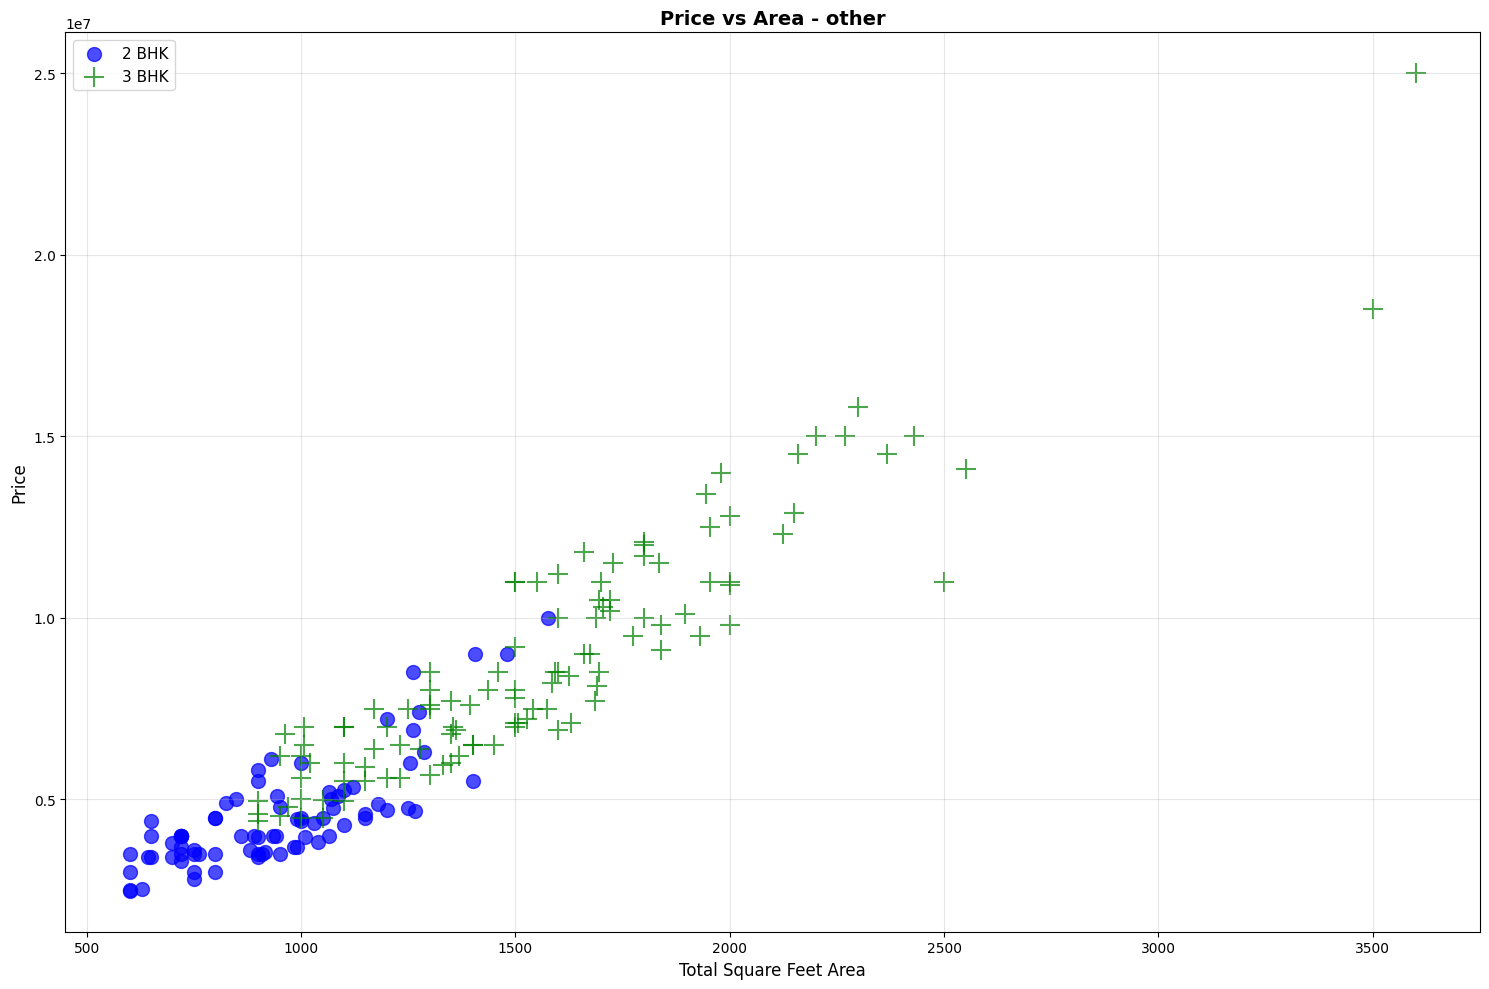


2 BHK count: 80, 3 BHK count: 112


In [118]:
plot_scatter_chart(df8)

Text(0.5, 1.0, 'Distribution of Price Per Square Feet')

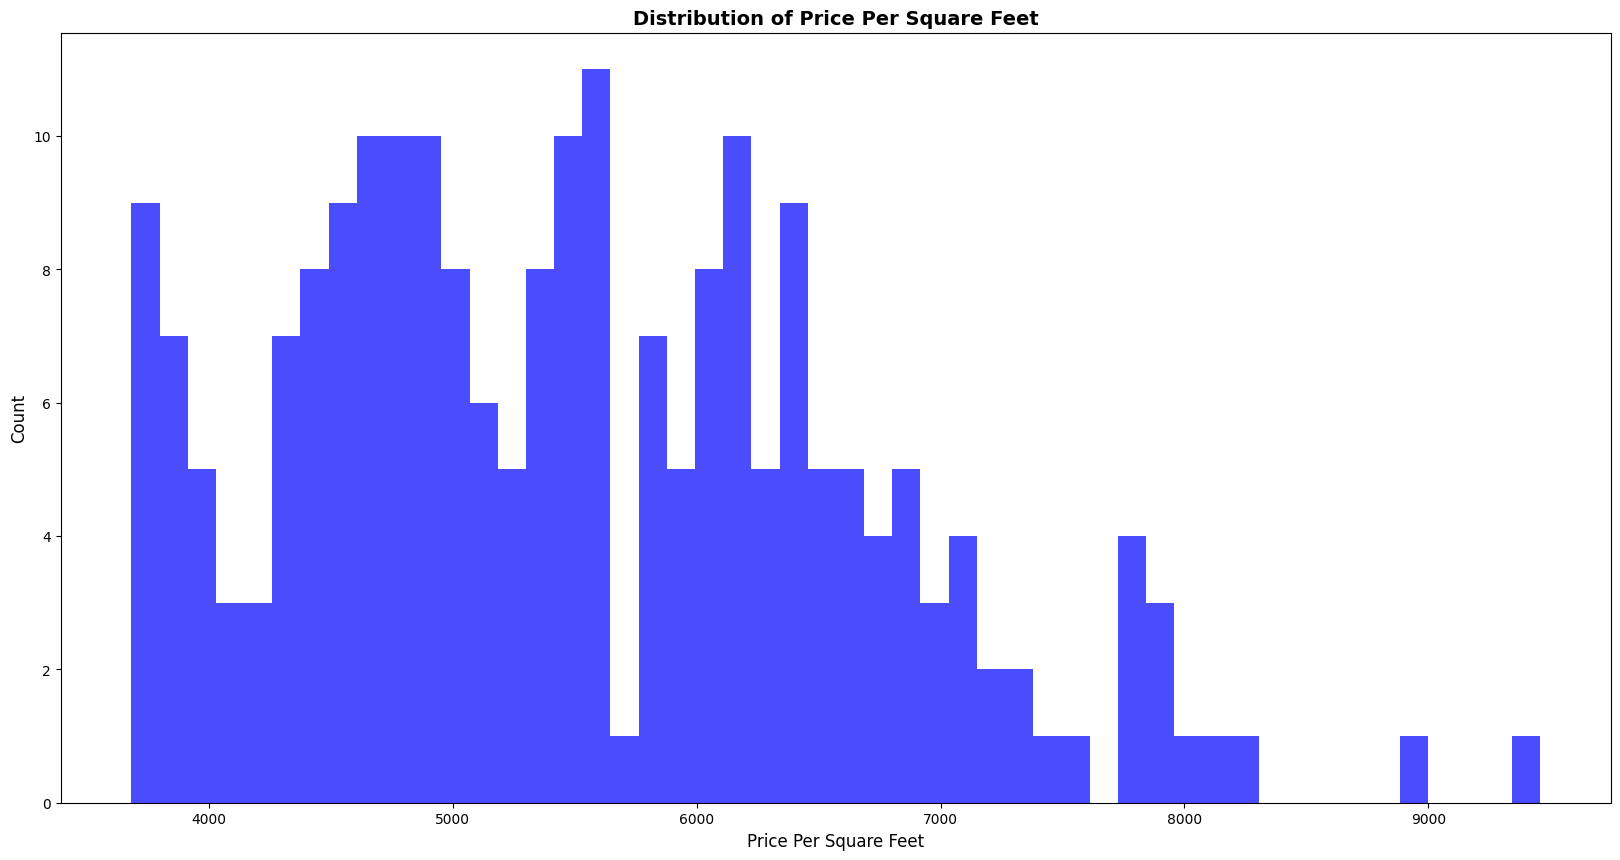

In [119]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20,10)
plt.hist(df8.price_per_sqft, bins=50, color='blue', alpha=0.7)
plt.xlabel("Price Per Square Feet", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Price Per Square Feet", fontsize=14, fontweight='bold')

In [120]:
df8.Bathrooms.unique()

array([2, 3, 4, 5])

In [121]:
df8[df8.Bathrooms>10]

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,...,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft,price_per_sqft,address


Text(0.5, 1.0, 'Distribution of Number of Bathrooms')

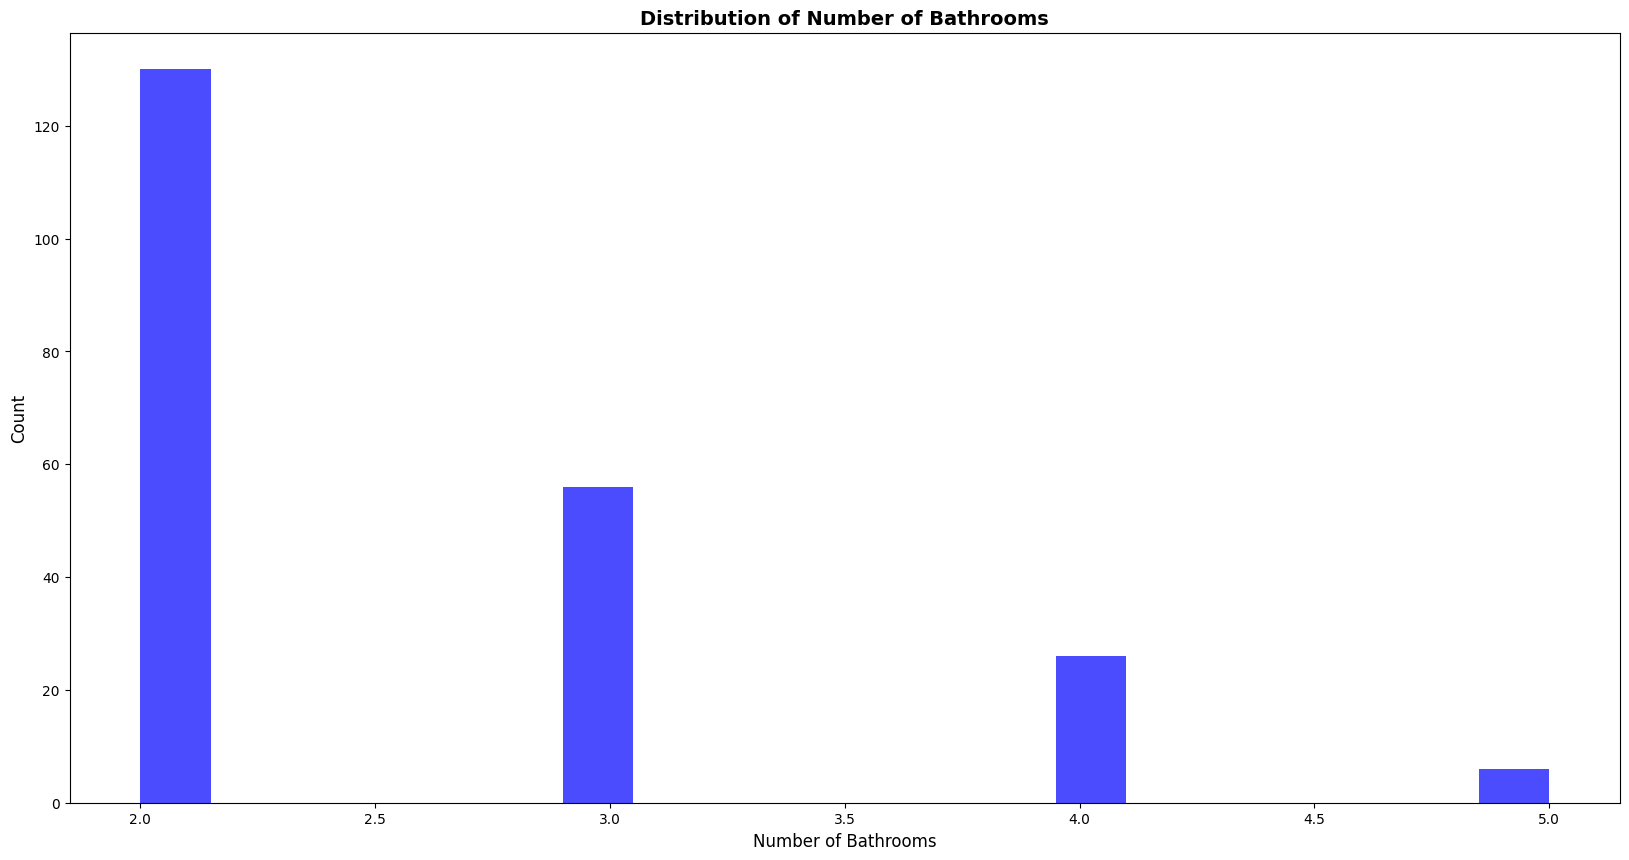

In [122]:
plt.hist(df8.Bathrooms, bins=20, color='blue', alpha=0.7)
plt.xlabel("Number of Bathrooms", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Number of Bathrooms", fontsize=14, fontweight='bold')

In [123]:
df8[df8.Bathrooms>df8.bhk+2]

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,...,Landmarks,type_of_building,desc,Price_sqft,area_type,size,bhk,total_sqft,price_per_sqft,address


In [124]:
df9 = df8[df8.Bathrooms<=df8.bhk+2]
df9.shape

(218, 22)

In [125]:
df10 =df9.drop(['area_type', 'size', 'price_per_sqft'], axis='columns', errors='ignore')
df10.head(3)

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,bhk,total_sqft,address
2,18,5100000.0,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.64431,77.331787,2,2,Resale,1.0,Semi-Furnished,2.0,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,2,1087.0,other
4,30,9000000.0,"sector 103 gurgaon, Dwarka Expressway, Gurgaon...",1481,28.49745,77.027092,2,2,Resale,2.0,Unfurnished,2.0,near gurgaon railway station,Flat,\n \n \n...,6076.975017,2,1481.0,other
5,38,4550000.0,"Krishna Park Colony, New Delhi - South, Delhi NCR",950,28.50809,77.231467,3,2,New Property,1.0,Semi-Furnished,1.0,The proprty is located nearby vishal mega mart,Flat,\n\n\n Devli Kh...,4789.473684,3,950.0,other


In [126]:
dummies =pd.get_dummies(df10.address)
dummies.head(3)

,other
2,True
4,True
5,True


In [127]:
df11 =pd.concat([df10, dummies.drop('other', axis='columns', errors='ignore')], axis='columns')
df11.head(3)

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,bhk,total_sqft,address
2,18,5100000.0,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.64431,77.331787,2,2,Resale,1.0,Semi-Furnished,2.0,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,2,1087.0,other
4,30,9000000.0,"sector 103 gurgaon, Dwarka Expressway, Gurgaon...",1481,28.49745,77.027092,2,2,Resale,2.0,Unfurnished,2.0,near gurgaon railway station,Flat,\n \n \n...,6076.975017,2,1481.0,other
5,38,4550000.0,"Krishna Park Colony, New Delhi - South, Delhi NCR",950,28.50809,77.231467,3,2,New Property,1.0,Semi-Furnished,1.0,The proprty is located nearby vishal mega mart,Flat,\n\n\n Devli Kh...,4789.473684,3,950.0,other


In [128]:
df12 = df11.drop('address', axis='columns', errors='ignore')
df12.head(2)

,Serial No.,price,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,bhk,total_sqft
2,18,5100000.0,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.64431,77.331787,2,2,Resale,1.0,Semi-Furnished,2.0,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,2,1087.0
4,30,9000000.0,"sector 103 gurgaon, Dwarka Expressway, Gurgaon...",1481,28.49745,77.027092,2,2,Resale,2.0,Unfurnished,2.0,near gurgaon railway station,Flat,\n \n \n...,6076.975017,2,1481.0


In [129]:
df12.shape

(218, 18)

In [130]:
x = df12.drop('price', axis='columns', errors='ignore')
x.head()

,Serial No.,Address,area,latitude,longitude,Bedrooms,Bathrooms,neworold,parking,Furnished_status,Lift,Landmarks,type_of_building,desc,Price_sqft,bhk,total_sqft
2,18,"NeelPadam Kunj, Vaishali, Sector 1, Ghaziabad,...",1087,28.644310,77.331787,2,2,Resale,1.0,Semi-Furnished,2.0,Prime location surrounded by malls and hospita...,Flat,\n\n\n Complex ...,4691.812328,2,1087.0
4,30,"sector 103 gurgaon, Dwarka Expressway, Gurgaon...",1481,28.497450,77.027092,2,2,Resale,2.0,Unfurnished,2.0,near gurgaon railway station,Flat,\n \n \n...,6076.975017,2,1481.0
5,38,"Krishna Park Colony, New Delhi - South, Delhi NCR",950,28.508090,77.231467,3,2,New Property,1.0,Semi-Furnished,1.0,The proprty is located nearby vishal mega mart,Flat,\n\n\n Devli Kh...,4789.473684,3,950.0
6,52,"Sector 104, Gurgaon, Sector 104, Gurgaon, Delh...",1689,28.487018,76.998009,3,3,New Property,1.0,Semi-Furnished,3.0,Bang on 150 mtr wide Dwarka Expressway . close...,Flat,\n\n\n A home w...,5920.663114,3,1689.0
7,55,"Sector 137, Noida, Sector 137, Noida, Delhi NCR",1685,28.509208,77.406626,3,4,Resale,1.0,Unfurnished,2.0,Sector 137 Metro Station,Flat,\n \n \n...,4569.732938,3,1685.0


In [131]:
y = df12.price
y.head()

,price
2,5100000.0
4,9000000.0
5,4550000.0
6,10000000.0
7,7700000.0


In [132]:
!pip install scikit-learn


In [133]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Drop non-numeric columns from df12 before splitting into X and y
# Assuming 'address' dummy variable was already created and original 'address' column dropped in df12 creation
df_numeric = df12.drop(['Address', 'neworold', 'Furnished_status', 'Landmarks', 'type_of_building', 'desc', 'Serial No.'], axis='columns', errors='ignore')

x = df_numeric.drop('price', axis='columns', errors='ignore')
y = df_numeric.price

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

ln_clf = LinearRegression()
ln_clf.fit(X_train, y_train)

ln_clf.score(X_test, y_test)

0.9669161227503623

In [134]:
# Predict price for test data
y_pred = ln_clf.predict(X_test)

print("Actual price:", y_test.iloc[0])
print("Predicted price:", y_pred[0])

Actual price: 6300000.0
Predicted price: 6697999.271678779


In [135]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 826338.7167230734
MSE: 1888319279976.3083
